*Comparação de Luminosidade: Compare o canal L∗ do CIELAB com o canal Y do YCbCr. Qual deles parece preservar melhor os detalhes de sombreamento da imagem original?*

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

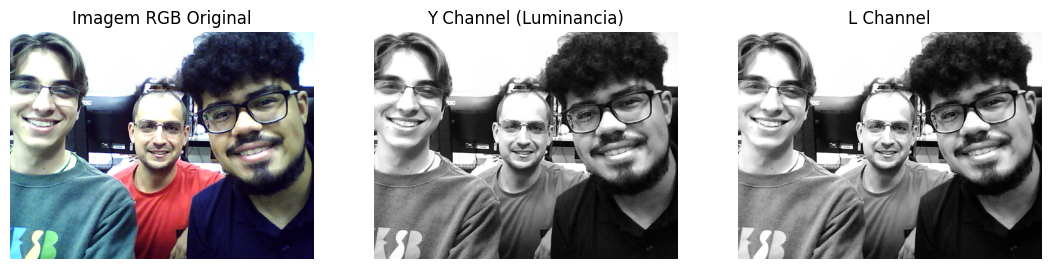

In [3]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('img/alunos.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def rgb_to_ycbcr(rgb_img):
  ycbcr_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2YCrCb)
  return ycbcr_img

def get_y_channel(ycbcr_img):
  Y_channel, Cr_channel, Cb_channel = cv2.split(ycbcr_img)
  return Y_channel


def rgb_to_cielab(rgb_img):
  cielab_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2Lab)
  return cielab_img

def get_l_channel(cielab_img):
  # 3. Separar os canais
  L_channel, A_channel, B_channel = cv2.split(cielab_img)
  return L_channel

Y_channel = get_y_channel(rgb_to_ycbcr(img))
L_channel = get_l_channel(rgb_to_cielab(img))

# Plotar a imagem original e os canais separados
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title('Imagem RGB Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(Y_channel, cmap='gray')
plt.title('Y Channel (Luminancia)')
plt.axis('off')


plt.subplot(1, 4, 3)
plt.imshow(L_channel, cmap='gray')
plt.title('L Channel')
plt.axis('off')


### ***Análise***

#### **O que é o espaço CIELAB**

O *CIELAB* é um espaço de cor projetado para ser perceptualmente uniforme, ou seja, diferenças numéricas correspondem melhor às diferenças percebidas pelo olho humano. Ele separa a informação em três componentes: L* (luminosidade), a* (verde–vermelho) e b* (azul–amarelo). O canal L* representa a claridade percebida, variando de preto a branco de forma não linear, ajustada à sensibilidade visual humana.

<p align="center">
  <img src="https://www.datacolor.com/wp-content/uploads/2023/09/CIELAB.jpg" width="300">
</p>

#### **O que é o espaço YCbCr**

O *YCbCr* é um espaço de cor muito utilizado em compressão de imagens e vídeos, que separa a imagem em Y (luminância) e dois canais de crominância (Cb e Cr). O canal Y é uma combinação linear dos valores RGB, representando o brilho da imagem, mas sem considerar a percepção não linear do olho humano.

<p align="center">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTzwLfUkDHyEAT7kVWM2EWgG8RclOH6JzHdWQ&s" width="300">
</p>

### ***Conclusão***

O canal L* apresenta melhor preservação dos detalhes de sombreamento, pois o espaço CIELAB modela a sensibilidade do olho humano à luminância. Já o canal Y do YCbCr é uma combinação linear dos canais RGB, não levando em conta a percepção não linear da visão humana, o que pode resultar em perda de detalhes em regiões de baixa iluminação.